# D1 自测结果表
|项目|自评(会/半会/不会)|优先级(高/中/低)|补法|
|----|----|----|----|
|pandas merge|会 |低 | |
|pandas crosstab/pivot|会 |低 | |
|pandas 缺失值+describe统计|会 |低 | |
|SQL JOIN| 会| | |
|SQL窗口函数| 会| | |
|sklearn train_test_split| 会| | |
|sklearn confusion_matrix| 不会| | |
|sklearn cross_val_score| 会| | |
|sklearn roc_auc_score| 不会| | |
|LightGBM调包| 会| | |
|Git/GitHub|不会|高|D1全天实操练习|


In [ ]:
import pandas as pd

# dataframe1 客户表，存在重复key，用于测试一对多合并
df1 = pd.DataFrame({
    "customer_id": [1001, 1002, 1002, 1003, 1004, 1005],
    "name": ["张三", "李四", "李四", "王五", "赵六", "孙七"],
    "city": ["上海", "北京", "北京", "广州", "深圳", "杭州"],
    "joined_date": pd.to_datetime(["2023-01-15", "2023-03-02", "2023-03-02", "2023-05-20", "2024-02-11", "2024-06-30"])
})

# dataframe2 订单表，包含df1不存在的customer_id=1006，测试left/right/outer连接NaN效果
df2 = pd.DataFrame({
    "order_id": ["A001", "A002", "A003", "A004", "A005"],
    "customer_id": [1001, 1002, 1003, 1006, 1001],
    "user_id": [9001, 9002, 9003, 9006, 9001],
    "amount": [199.0, 358.5, 89.0, 1200.0, 45.5],
    "order_date": pd.to_datetime(["2023-06-10", "2023-07-22", "2023-09-01", "2024-01-15", "2024-03-05"])
})

# 示例merge调用，你可以注释掉，自行测试 how 参数：inner / left / right / outer
df_merge = pd.merge(df1, df2, on="customer_id", how="inner")
print("\n==== merge inner结果 ====")
df_merge


==== df1 ====
   customer_id name city joined_date
0         1001   张三   上海  2023-01-15
1         1002   李四   北京  2023-03-02
2         1002   李四   北京  2023-03-02
3         1003   王五   广州  2023-05-20
4         1004   赵六   深圳  2024-02-11
5         1005   孙七   杭州  2024-06-30

==== df2 ====
  order_id  customer_id  user_id  amount order_date
0     A001         1001     9001   199.0 2023-06-10
1     A002         1002     9002   358.5 2023-07-22
2     A003         1003     9003    89.0 2023-09-01
3     A004         1006     9006  1200.0 2024-01-15
4     A005         1001     9001    45.5 2024-03-05

==== merge inner结果 ====


,customer_id,name,city,joined_date,order_id,user_id,amount,order_date
0,1001,张三,上海,2023-01-15,A001,9001,199.0,2023-06-10
1,1001,张三,上海,2023-01-15,A005,9001,45.5,2024-03-05
2,1002,李四,北京,2023-03-02,A002,9002,358.5,2023-07-22
3,1002,李四,北京,2023-03-02,A002,9002,358.5,2023-07-22
4,1003,王五,广州,2023-05-20,A003,9003,89.0,2023-09-01


In [ ]:
"""
sklearn 5个分类常用API自查示例：
train_test_split、confusion_matrix、cross_val_score、roc_auc_score、classification_report
数据集：内置鸢尾花二分类改造，仅0/1两类，方便ROC‑AUC计算
"""
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, roc_auc_score, classification_report
from sklearn.linear_model import LogisticRegression

# ---------------------- 1. 准备数据，转为二分类任务 ----------------------
data = load_iris()
X = data.data[:100, :]   # 取前100样本：0、1两类
y = data.target[:100]

# ========== 1.train_test_split：划分训练集、测试集 ==========
# X_train：训练特征，X_test：测试特征
# y_train：训练标签，y_test：测试标签
# test_size=0.2：20%作为测试集；random_state固定随机种子保证复现；stratify=y按标签比例分层抽样
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 训练简单逻辑回归模型
clf = LogisticRegression(random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)                # 测试集预测标签 0/1
y_pred_proba = clf.predict_proba(X_test)[:,1]# 预测为类别1的概率，用于AUC

# ========== 2.confusion_matrix 混淆矩阵 ==========
# 输出格式 [[TN, FP],
#          [FN, TP]]
# TN真负：真实0预测0；FP假正：真实0预测1
# FN假负：真实1预测0；TP真正：真实1预测1
cm = confusion_matrix(y_test, y_pred)
print("=== confusion_matrix 混淆矩阵 ===")
print(cm)

# ========== 3.classification_report分类报告：精确率、召回率、F1、支持样本数 ==========
# precision精确率：预测为该类里真实为该类占比 TP/(TP+FP)
# recall召回率：真实该类里被预测出来占比 TP/(TP+FN)
# f1‑score：精确率召回率调和平均 2*(P*R)/(P+R)
# support：该类别真实样本数量
print("\n=== classification_report 分类报告 ===")
print(classification_report(y_test, y_pred, target_names=["类别0","类别1"]))

# ========== 4.roc_auc_score ROC‑AUC得分 ==========
# AUC取值[0,1]；越接近1模型区分能力越好；0.5等价随机猜测
# 输入需要正类概率，不是预测标签！
auc = roc_auc_score(y_test, y_pred_proba)
print(f"\n=== roc_auc_score = {auc:.4f} ===")

# ========== 5.cross_val_score 交叉验证得分 ==========
# cv=5：5折交叉验证；scoring='roc_auc'使用AUC作为评估指标
# 返回每一轮验证集得分；mean取平均得分评估模型泛化能力
cv_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring="roc_auc")
print("\n=== cross_val_score 5折AUC每折得分 ===")
print(cv_scores)
print(f"5折平均AUC: {np.mean(cv_scores):.4f}, 标准差: {np.std(cv_scores):.4f}")


[[0.15675163 0.84324837]
 [0.00146681 0.99853319]
 [0.00471418 0.99528582]
 [0.00718105 0.99281895]
 [0.97626711 0.02373289]
 [0.98809707 0.01190293]
 [0.95541954 0.04458046]
 [0.00749321 0.99250679]
 [0.95813802 0.04186198]
 [0.99442176 0.00557824]
 [0.98684267 0.01315733]
 [0.00490797 0.99509203]
 [0.97928481 0.02071519]
 [0.98461217 0.01538783]
 [0.97680088 0.02319912]
 [0.13994122 0.86005878]
 [0.03288835 0.96711165]
 [0.9787077  0.0212923 ]
 [0.00485122 0.99514878]
 [0.01045182 0.98954818]]
=== confusion_matrix 混淆矩阵 ===
[[10  0]
 [ 0 10]]

=== classification_report 分类报告 ===
              precision    recall  f1-score   support

         类别0       1.00      1.00      1.00        10
         类别1       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20


=== roc_auc_score = 1.0000 ===

=== cross_val_score 5折AUC每折得分 ===
[1. 1. 1. 1. 1.]
5折平

## 题目 1：读取 csv 基础统计

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ==========直接生成测试数据（不需要外部文件）==========
np.random.seed(42)
n_rows = 300
df = pd.DataFrame({
    "user_id": list(range(n_rows)),
    "age": np.random.randint(18, 60, size=n_rows),
    "monthly_fee": np.round(np.random.uniform(20,120,size=n_rows),2),
    "is_vip": np.random.choice([0,1], size=n_rows, p=[0.7,0.3]),
})
# 人为制造部分缺失值
df.loc[np.random.choice(df.index, 15), "age"] = np.nan

# 可选：如果你想模拟读csv，把内存df保存成本地文件再读取
df.to_csv("./test_d1.csv", index=False)
df = pd.read_csv("./test_d1.csv")


In [2]:
# ----------------任务开始，请补全代码----------------
# 任务1：统计每列缺失数量
df.isnull().sum()
# missing = ____________
# print("每列缺失值:\n", missing)


user_id         0
age            14
monthly_fee     0
is_vip          0
dtype: int64

          user_id         age  monthly_fee      is_vip
count  300.000000  286.000000   300.000000  300.000000
mean   149.500000   39.108392    68.931033    0.313333
std     86.746758   12.420080    29.075307    0.464624
min      0.000000   18.000000    20.520000    0.000000
25%     74.750000   28.000000    45.022500    0.000000
50%    149.500000   41.000000    67.380000    0.000000
75%    224.250000   50.000000    93.295000    1.000000
max    299.000000   59.000000   119.590000    1.000000


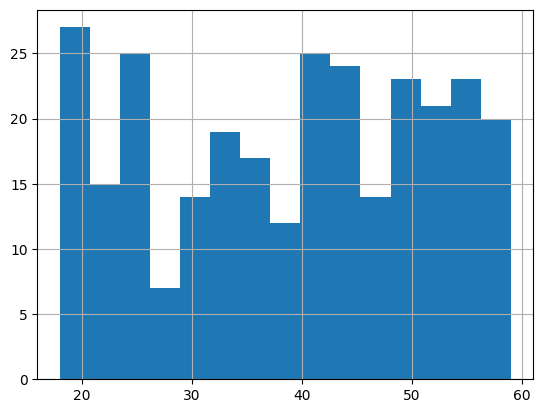

In [3]:
# 任务2：数值列describe描述统计
print(df.describe())

# 任务3：对 age 列绘制hist直方图
df['age'].hist(bins=15)
plt.show()


## 题目 2：字典频次统计，输出频次 Top5

In [6]:
data_list = ["apple","banana","apple","orange","banana","apple","pear",
             "banana","grape","apple","pear","banana","orange","apple","grape"]

freq_dict = {}
# --------你的代码写这里：用dict完成计数--------
for i in data_list:
    if i not in freq_dict.keys():
        freq_dict[i] = 1
    else:
        freq_dict[i] += 1

freq_dict

# 字典频次统计，输出频次 Top5
freq_dict_sorted = sorted(freq_dict.items(), key=lambda x: x[1], reverse=True)
print(freq_dict_sorted[:5])

[('apple', 5), ('banana', 4), ('orange', 2), ('pear', 2), ('grape', 2)]


## 题目 3：封装函数 summarize_csv，增加异常捕获 try‑except

In [10]:
def summarize_csv(path, col, top_n=5):
    try:
        df = pd.read_csv(path)[col]

    except FileNotFoundError:
        print(f"File not found: {path}")
        return None
    except KeyError:
        print(f"Column not found: {col}")
        return None
    except pd.errors.ParserError:
        print(f"Error parsing file: {path}")

    df = df.value_counts().nlargest(top_n)
    return df

# =========测试调用，使用上面生成的test_d1.csv=========
print(summarize_csv("./test_d1.csv", "is_vip", top_n=3))
# 故意传入错误路径测试异常逻辑
print(summarize_csv("./not_exist_file.csv", "is_vip"))
# 故意传入不存在列名测试异常逻辑
print(summarize_csv("./test_d1.csv", "not_exist_col"))

is_vip
0    206
1     94
Name: count, dtype: int64
File not found: ./not_exist_file.csv
None
Column not found: not_exist_col
None


In [2]:
pip install lightgbm

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
    --------------------------------------- 0.0/1.4 MB 435.7 kB/s eta 0:00:04
   - -------------------------------------- 0.1/1.4 MB 465.5 kB/s eta 0:00:03
   --- ------------------------------------ 0.1/1.4 MB 656.4 kB/s eta 0:00:02
   ---- ----------------------------------- 0.1/1.4 MB 655.8 kB/s eta 0:00:02
   ---- ----------------------------------- 0.1/1.4 MB 655.8 kB/s eta 0:00:02
   -------- ------------------------------- 0.3/1.4 MB 850.6 kB/s eta 0:00:02
   -------- ------------------------------- 0.3/1.4 MB 850.6 kB/s eta 0:00:02
   --------- ------------------------------ 0.3/1.4 MB 807.1 kB/s eta 0:00:02
   --------- ------------------------------ 0.3/1.4 MB 807.1 kB/s eta 0:00:02
   --------- ------------------------------ 0.3/1.4 MB 807.1 kB/s eta 0:00:02
   ----------------- ---------------------- 0.6/1.4 MB 1.2 MB/s eta 0:00:01
   ---